## 0.7 선형 변환과 회전

회전 행렬의 변환을 시각화하고 단일 큐비트 게이트(행렬 예시)를 확인한 뒤, 심화로 게이트가 블로흐 구 회전임을 본다.

In [ ]:
%pip install -q qiskit

### 0.7.1~0.7.2 선형 변환과 회전 행렬 (길이 보존)

|v| = 2.5 , |R(50°)v| = 2.5


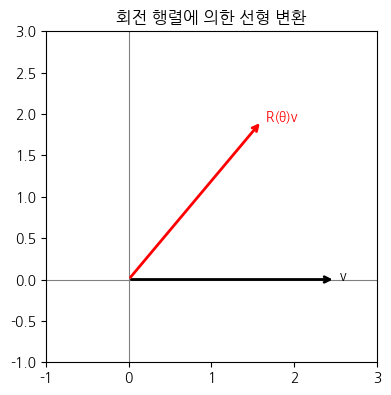

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
%matplotlib inline

def R(t): return np.array([[np.cos(t),-np.sin(t)],[np.sin(t),np.cos(t)]])
v = np.array([2.5,0.0]); w = R(np.radians(50)) @ v
print("|v| =", np.linalg.norm(v), ", |R(50°)v| =", round(np.linalg.norm(w),3))
fig,ax=plt.subplots(figsize=(4.3,4.3))
ax.axhline(0,color='gray',lw=.8); ax.axvline(0,color='gray',lw=.8)
ax.annotate("",xy=v,xytext=(0,0),arrowprops=dict(arrowstyle="->",color="black",lw=2))
ax.annotate("",xy=w,xytext=(0,0),arrowprops=dict(arrowstyle="->",color="red",lw=2))
ax.text(*v," v"); ax.text(*w," R(θ)v",color="red")

ax.set_xlim(-1,3); ax.set_ylim(-1,3); 
ax.set_aspect("equal"); 
ax.set_title("회전 행렬에 의한 선형 변환"); 
plt.show()

### 0.7.3 게이트의 행렬 표현 (동작·회로는 Part 1.3)

In [2]:
import numpy as np

ket0 = np.array([1,0])
X = np.array([[0,1],[1,0]]); H = (1/np.sqrt(2))*np.array([[1,1],[1,-1]])
print("X|0> =", X@ket0, " (비트 반전)")
print("H|0> =", np.round(H@ket0,3), " (균등 중첩)")

X|0> = [0 1]  (비트 반전)
H|0> = [0.707 0.707]  (균등 중첩)


### 0.7.4 심화: SU(2)·SO(3)와 큐비트 회전
단일 큐비트 게이트는 블로흐 구 위 블로흐 벡터의 3차원 회전에 대응한다. R_y 회전을 적용해 직접 확인한다.

상태벡터: [0.866+0.j 0.5  +0.j]
측정 확률: {np.str_('0'): np.float64(0.7500000000000001), np.str_('1'): np.float64(0.24999999999999994)}


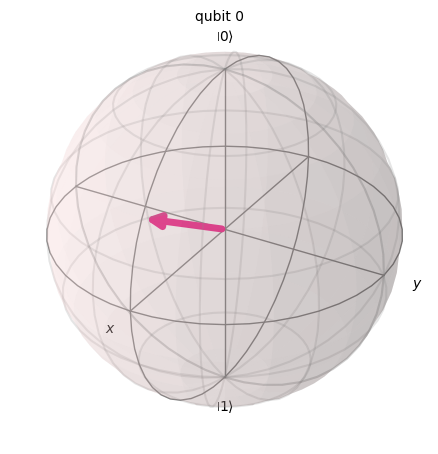

In [3]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt
%matplotlib inline

# |0>에 R_y(θ)를 적용하면 블로흐 구에서 y축 둘레로 회전
qc = QuantumCircuit(1)
qc.ry(np.pi/3, 0)   # 60도 회전
sv = Statevector(qc)
print("상태벡터:", np.round(sv.data,3))
print("측정 확률:", sv.probabilities_dict())
plot_bloch_multivector(sv); plt.show()

In [4]:
import numpy as np
# R_z 는 위상만 바꿈 -> 블로흐 구에서 z축 회전, 측정 확률(P0,P1)은 불변
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

base = QuantumCircuit(1); base.h(0)
p_before = Statevector(base).probabilities()
qc = QuantumCircuit(1); qc.h(0); qc.rz(np.pi/2, 0)
p_after = Statevector(qc).probabilities()
print("Rz 적용 전 P:", np.round(p_before,4))
print("Rz 적용 후 P:", np.round(p_after,4), " (z축 회전 -> 확률 불변, 위상만 변화)")

Rz 적용 전 P: [0.5 0.5]
Rz 적용 후 P: [0.5 0.5]  (z축 회전 -> 확률 불변, 위상만 변화)
